# Figure 2 — CI width of the probability shift $d$ vs rule support (B&W)

Scatter plot of 95\% bootstrap CI width for the *unscaled probability shift* $d = \text{conf}(r_2) + \text{conf}(r_1) - 1$ versus rule support, across all four article datasets.

**Why $d$ and not the population-level uplift $\hat{\upsilon} = d \cdot n_u / N$?** For the population-level uplift, the Wald SE is $(n_u/N)\sqrt{p_u(1-p_u)/n_u + p_d(1-p_d)/n_d}$, which grows roughly as $\sqrt{n_u}/N$ when $n_u$ and $n_d$ scale together — so its width *increases* with support, not decreases. Plotting the unscaled shift $d$ isolates the standard binomial $1/\sqrt{n}$ shrinkage that the analytic Wald variance captures.

Mechanically, we derive the $d$-width by multiplying each rule's uplift CI width by $N/n_u$. This is exact for Wald and Wilson (which condition on counts) and a tight approximation for the bootstrap (where $n_u$ varies slightly across replicates).

Datasets are distinguished by marker shape (rendered in grayscale fill).

**Output:** `article/figures/fig2_ci_width_vs_support.pdf`.

In [1]:
from __future__ import annotations
import sys
from pathlib import Path
import numpy as np
import pandas as pd
REPO = Path.cwd()
while not (REPO / 'pyproject.toml').exists() and REPO != REPO.parent:
    REPO = REPO.parent
if str(REPO / 'notebooks' / 'article' / 'figures') not in sys.path:
    sys.path.insert(0, str(REPO / 'notebooks' / 'article' / 'figures'))
from _style import DOUBLE_COL_INCHES, DATASET_MARKER, apply_rc
import matplotlib.pyplot as plt
apply_rc()
CSV = REPO / 'article' / 'results' / 'rule_level_cis.csv'
PDF = REPO / 'article' / 'figures' / 'fig2_ci_width_vs_support.pdf'

# Dataset sizes used to recover the unscaled shift d from the population-level
# uplift CI: width(d) = width(uplift) * N / n_u.  Hardcoded because the
# rule_level_cis.csv does not carry N; values match _datasets.load_all().
DATASET_N = {
    'Telco Customer Churn': 7043,
    'UCI Bank Marketing': 41188,
    'IBM Employee Attrition': 1470,
    'Taiwan Credit Card Default': 30000,
}

df = pd.read_csv(CSV)
df = df[df['method'] == 'bootstrap_percentile'].copy()
df['uplift_width'] = df['uplift_ci_upper'] - df['uplift_ci_lower']
df = df[df['support'] > 0]
df['N'] = df['dataset'].map(DATASET_N)
df = df[df['N'].notna()]
df['d_width'] = df['uplift_width'] * df['N'] / df['support']
print(df.shape, df['dataset'].value_counts().to_dict())

(89, 16) {'Telco Customer Churn': 24, 'UCI Bank Marketing': 24, 'IBM Employee Attrition': 21, 'Taiwan Credit Card Default': 20}


wrote article\figures\fig2_ci_width_vs_support.pdf


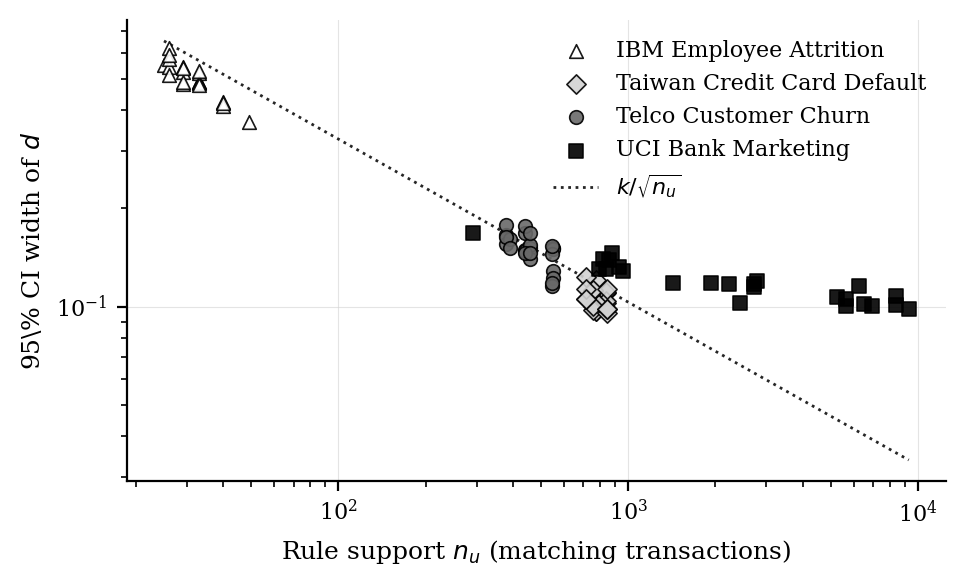

In [2]:
fig, ax = plt.subplots(figsize=(DOUBLE_COL_INCHES * 0.7, 3.0))
fill_cycle = {'IBM Employee Attrition': 'white',
              'Taiwan Credit Card Default': 'lightgray',
              'Telco Customer Churn': 'dimgray',
              'UCI Bank Marketing': 'black'}

for name, sub in df.groupby('dataset'):
    marker = DATASET_MARKER.get(name, 'o')
    face = fill_cycle.get(name, 'lightgray')
    ax.scatter(sub['support'], sub['d_width'],
               marker=marker, facecolor=face, edgecolor='black', linewidth=0.6,
               s=24, alpha=0.9, label=name, zorder=3)

# Reference 1/sqrt(n) curve anchored at the overall median data point.  With
# all four datasets calibrated to ~20 rules each, a single global anchor is
# now representative; per-dataset constants no longer diverge dramatically.
median_support = df['support'].median()
median_d_width = df['d_width'].median()
k = median_d_width * np.sqrt(median_support)
xref = np.geomspace(max(df['support'].min(), 1), df['support'].max(), 200)
ax.plot(xref, k / np.sqrt(xref), color='black', linestyle=':', linewidth=1.0,
        label=r'$k/\sqrt{n_u}$', alpha=0.85)
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel('Rule support $n_u$ (matching transactions)')
ax.set_ylabel(r'95\% CI width of $d$')
ax.legend(loc='upper right', frameon=False)
ax.grid(True, which='major', color='lightgray', linewidth=0.4, alpha=0.6)
fig.tight_layout()
fig.savefig(PDF, format='pdf', bbox_inches='tight')
print('wrote', PDF.relative_to(REPO))
plt.show()